In [ ]:
## Brain Tumor Classification - Model Comparison

In [ ]:
## 1. Setup and Data Loading

In [ ]:

import os
os.environ["KAGGLE_USERNAME"] = "your_username"
os.environ["KAGGLE_KEY"] = "your_api_key"

!pip install -q kaggle
!kaggle datasets list

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content --unzip

In [ ]:
!ls -la /content
!find /content -maxdepth 2 -type d -name "Training" -o -name "Testing"

In [ ]:
##2. Data Split and Preprocessing

In [ ]:

import random, shutil
from pathlib import Path

random.seed(42)

src_train = Path("/content/Training")
src_test  = Path("/content/Testing")

dst_root  = Path("/content/data")
dst_train = dst_root / "train"
dst_val   = dst_root / "val"
dst_test  = dst_root / "test"

if dst_root.exists():
    shutil.rmtree(dst_root)

shutil.copytree(src_test, dst_test)

# training/validation split
VAL_FRAC = 0.15
classes = [d.name for d in src_train.iterdir() if d.is_dir()]
print("Classes found:", classes)

for c in classes:
    imgs = list((src_train / c).glob("*"))
    imgs = [p for p in imgs if p.is_file()]
    random.shuffle(imgs)

    n_val = int(len(imgs) * VAL_FRAC)

    (dst_train / c).mkdir(parents=True, exist_ok=True)
    (dst_val / c).mkdir(parents=True, exist_ok=True)

    for p in imgs[:n_val]:
        shutil.copy2(p, dst_val / c / p.name)
    for p in imgs[n_val:]:
        shutil.copy2(p, dst_train / c / p.name)

print("Split complete.")

Classes found: ['pituitary', 'notumor', 'meningioma', 'glioma']
Split complete.


In [ ]:
from pathlib import Path

for split in ["train", "val", "test"]:
    print("\n", split.upper())
    base = Path("/content/data") / split
    for c in sorted([d.name for d in base.iterdir() if d.is_dir()]):
        print(c, ":", len(list((base/c).glob("*"))))

In [ ]:
import tensorflow as tf
import os
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = (256, 256)
BATCH = 32
SEED = 42

train_dir = "/content/data/train"
val_dir = "/content/data/val"
test_dir = "/content/data/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode = "categorical",
    image_size = IMG_SIZE,
    batch_size = BATCH,
    shuffle = True,
    seed = SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names, "num_classes", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
## Data augmentation

In [ ]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
from tensorflow.keras import layers, models

base = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256, 256,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 256, 256)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 256, 256)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 256, 256)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 256, 256,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │      8,196 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 14,458,372 (55.15 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "resnet50_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test acc:", test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.9275 - loss: 0.3296
Test acc: 0.9275000095367432


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Get y_true and y_pred
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step
Confusion Matrix:
 [[319  51  26   4]
 [  4 380   6  10]
 [  0   0 400   0]
 [  0   1   0 399]]

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9876    0.7975    0.8824       400
  meningioma     0.8796    0.9500    0.9135       400
     notumor     0.9259    1.0000    0.9615       400
   pituitary     0.9661    0.9975    0.9815       400

    accuracy                         0.9363      1600
   macro avg     0.9398    0.9363    0.9347      1600
weighted avg     0.9398    0.9363    0.9347      1600



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
## DenseNet preprocessing

In [ ]:

from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

In [ ]:
##3. DenseNet first run - 30 layers unfrozen

In [ ]:

from tensorflow.keras import layers, models

base_dense = tf.keras.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)
base_dense.trainable = True
for layer in base_dense.layers[:-30]:
    layer.trainable = False

inputs = layers.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = densenet_preprocess(x)
x = base_dense(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

dense_model = models.Model(inputs, outputs)

dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
dense_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 645,508 (2.46 MB)

 Non-trainable params: 6,396,096 (24.40 MB)

In [ ]:
callbacks_dense = [
    tf.keras.callbacks.ModelCheckpoint(
        "densenet121_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

history_dense = dense_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_dense
)

Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 62s 289ms/step - accuracy: 0.3532 - loss: 1.4785 - val_accuracy: 0.5405 - val_loss: 1.0624 - learning_rate: 1.0000e-05
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 238ms/step - accuracy: 0.5401 - loss: 1.0831 - val_accuracy: 0.7024 - val_loss: 0.8108 - learning_rate: 1.0000e-05
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 42s 244ms/step - accuracy: 0.6410 - loss: 0.8839 - val_accuracy: 0.7845 - val_loss: 0.6611 - learning_rate: 1.0000e-05
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 236ms/step - accuracy: 0.6935 - loss: 0.7703 - val_accuracy: 0.8143 - val_loss: 0.5650 - learning_rate: 1.0000e-05
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 36s 239ms/step - accuracy: 0.7460 - loss: 0.6619 - val_accuracy: 0.8345 - val_loss: 0.5025 - learning_rate: 1.0000e-05
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 36s 238ms/step - accuracy: 0.7733 - loss: 0.6123 - val_accuracy: 0.8452 - val_loss: 0.4604 - learning_rate: 1.0000e-05
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 23

In [ ]:
test_loss_d, test_acc_d = dense_model.evaluate(test_ds)
print("DenseNet121 Test acc:", test_acc_d)

y_pred_probs_d = dense_model.predict(test_ds)
y_pred_d = np.argmax(y_pred_probs_d, axis=1)

cm_d = confusion_matrix(y_true, y_pred_d)
print("Confusion Matrix:\n", cm_d)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_d, target_names=class_names, digits=4))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.8150 - loss: 0.5236
DenseNet121 Test acc: 0.8149999976158142
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 174ms/step
Confusion Matrix:
 [[256  83  39  22]
 [ 29 270  33  68]
 [  1   7 391   1]
 [  4   8   1 387]]

Classification Report:
              precision    recall  f1-score   support

      glioma     0.8828    0.6400    0.7420       400
  meningioma     0.7337    0.6750    0.7031       400
     notumor     0.8427    0.9775    0.9051       400
   pituitary     0.8096    0.9675    0.8815       400

    accuracy                         0.8150      1600
   macro avg     0.8172    0.8150    0.8079      1600
weighted avg     0.8172    0.8150    0.8079      1600



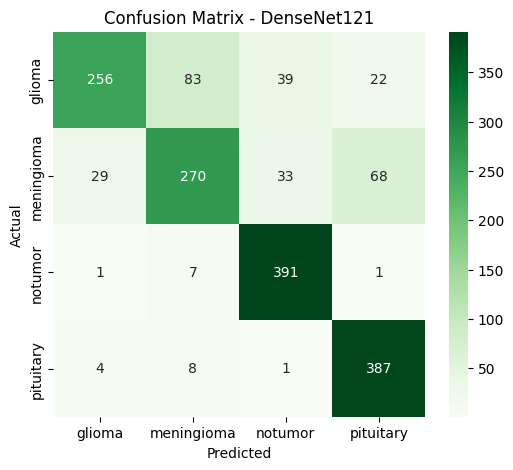

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_d, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DenseNet121")
plt.show()

In [ ]:
print("========== MODEL COMPARISON ==========")
print(f"ResNet50  (frozen baseline) : 84.69%")
print(f"ResNet50  (fine-tuned)      : {test_acc*100:.2f}%")
print(f"DenseNet121 (fine-tuned)    : {test_acc_d*100:.2f}%")

========== MODEL COMPARISON ==========
ResNet50  (frozen baseline) : 84.69%
ResNet50  (fine-tuned)      : 92.75%
DenseNet121 (fine-tuned)    : 81.50%


In [ ]:
##4. DenseNet second run - 60 layers unfrozen

In [ ]:

base_dense_v2 = tf.keras.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)
base_dense_v2.trainable = True
for layer in base_dense_v2.layers[:-60]:
    layer.trainable = False

inputs = layers.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.densenet.preprocess_input(x)
x = base_dense_v2(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

dense_model_v2 = models.Model(inputs, outputs)

dense_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
dense_model_v2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_2 (Add)                     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 1,255,172 (4.79 MB)

 Non-trainable params: 5,786,432 (22.07 MB)

In [ ]:
callbacks_dense_v2 = [
    tf.keras.callbacks.ModelCheckpoint(
        "densenet121_v2_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

history_dense_v2 = dense_model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_dense_v2
)

Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 62s 289ms/step - accuracy: 0.6019 - loss: 1.0630 - val_accuracy: 0.8274 - val_loss: 0.5015 - learning_rate: 3.0000e-05
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 37s 251ms/step - accuracy: 0.8145 - loss: 0.5047 - val_accuracy: 0.8583 - val_loss: 0.3710 - learning_rate: 3.0000e-05
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 37s 250ms/step - accuracy: 0.8630 - loss: 0.3903 - val_accuracy: 0.8833 - val_loss: 0.3151 - learning_rate: 3.0000e-05
Epoch 4/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 37s 251ms/step - accuracy: 0.8855 - loss: 0.3268 - val_accuracy: 0.8917 - val_loss: 0.2860 - learning_rate: 3.0000e-05
Epoch 5/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 37s 251ms/step - accuracy: 0.8964 - loss: 0.2871 - val_accuracy: 0.9036 - val_loss: 0.2563 - learning_rate: 3.0000e-05
Epoch 6/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 36s 241ms/step - accuracy: 0.9040 - loss: 0.2617 - val_accuracy: 0.9036 - val_loss: 0.2353 - learning_rate: 3.0000e-05
Epoch 7/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 38s 25

In [ ]:
test_loss_d2, test_acc_d2 = dense_model_v2.evaluate(test_ds)
print("DenseNet121 v2 Test acc:", test_acc_d2)

y_pred_probs_d2 = dense_model_v2.predict(test_ds)
y_pred_d2 = np.argmax(y_pred_probs_d2, axis=1)

cm_d2 = confusion_matrix(y_true, y_pred_d2)
print("Confusion Matrix:\n", cm_d2)
print("\nClassification Report:")
print(classification_report(y_true, y_pred_d2, target_names=class_names, digits=4))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.9112 - loss: 0.3432
DenseNet121 v2 Test acc: 0.9112499952316284
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step
Confusion Matrix:
 [[320  36  35   9]
 [ 14 341  14  31]
 [  1   0 399   0]
 [  0   2   0 398]]

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9552    0.8000    0.8707       400
  meningioma     0.8997    0.8525    0.8755       400
     notumor     0.8906    0.9975    0.9410       400
   pituitary     0.9087    0.9950    0.9499       400

    accuracy                         0.9113      1600
   macro avg     0.9136    0.9113    0.9093      1600
weighted avg     0.9136    0.9113    0.9093      1600



In [ ]:
print("========== FULL MODEL COMPARISON ==========")
print(f"ResNet50  (frozen baseline)    : 84.69%")
print(f"ResNet50  (fine-tuned)         : {test_acc*100:.2f}%")
print(f"DenseNet121 v1 (30 layers, lr=1e-5) : {test_acc_d*100:.2f}%")
print(f"DenseNet121 v2 (60 layers, lr=3e-5) : {test_acc_d2*100:.2f}%")

========== FULL MODEL COMPARISON ==========
ResNet50  (frozen baseline)    : 84.69%
ResNet50  (fine-tuned)         : 92.75%
DenseNet121 v1 (30 layers, lr=1e-5) : 81.50%
DenseNet121 v2 (60 layers, lr=3e-5) : 91.12%


In [ ]:
##5. Custom CNN - Version 1

In [ ]:

from tensorflow.keras import layers, models

def build_custom_cnn(num_classes, input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)

custom_cnn = build_custom_cnn(num_classes)
custom_cnn.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds_cnn = train_ds.map(augment)
val_ds_cnn   = val_ds.map(normalize)
test_ds_cnn  = test_ds.map(normalize)

In [ ]:
callbacks_cnn = [
    tf.keras.callbacks.ModelCheckpoint(
        "custom_cnn_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    )
]

history_cnn = custom_cnn.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=30,
    callbacks=callbacks_cnn
)

Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.6754 - loss: 0.8243 - val_accuracy: 0.3095 - val_loss: 2.5897 - learning_rate: 0.0010
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.7609 - loss: 0.6247 - val_accuracy: 0.2750 - val_loss: 2.8070 - learning_rate: 0.0010
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - accuracy: 0.7845 - loss: 0.5600 - val_accuracy: 0.4940 - val_loss: 2.1409 - learning_rate: 0.0010
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.8107 - loss: 0.5084 - val_accuracy: 0.2655 - val_loss: 4.6334 - learning_rate: 0.0010
Epoch 5/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.8284 - loss: 0.4702 - val_accuracy: 0.3167 - val_loss: 2.8208 - learning_rate: 0.0010
Epoch 6/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.8265 - loss: 0.4583 - val_accuracy: 0.4286 - val_loss: 1.5413 - learning_rate: 0.0010
Epoch 7/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - accuracy: 0.8

In [ ]:
test_loss_cnn, test_acc_cnn = custom_cnn.evaluate(test_ds_cnn)
print("Custom CNN Test acc:", test_acc_cnn)

y_pred_probs_cnn = custom_cnn.predict(test_ds_cnn)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
print("Confusion Matrix:\n", cm_cnn)
print("\nClassification Report:")
print(classification_report(y_true, y_pred_cnn, target_names=class_names, digits=4))

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8369 - loss: 0.6993
Custom CNN Test acc: 0.8368750214576721
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step
Confusion Matrix:
 [[253  77  46  24]
 [  3 286  54  57]
 [  0   0 400   0]
 [  0   0   0 400]]

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9883    0.6325    0.7713       400
  meningioma     0.7879    0.7150    0.7497       400
     notumor     0.8000    1.0000    0.8889       400
   pituitary     0.8316    1.0000    0.9081       400

    accuracy                         0.8369      1600
   macro avg     0.8519    0.8369    0.8295      1600
weighted avg     0.8519    0.8369    0.8295      1600



In [ ]:
print("========== FULL MODEL COMPARISON ==========")
print(f"ResNet50  (frozen baseline)         : 84.69%")
print(f"ResNet50  (fine-tuned)              : {test_acc*100:.2f}%")
print(f"DenseNet121 v1 (30 layers, lr=1e-5) : {test_acc_d*100:.2f}%")
print(f"DenseNet121 v2 (60 layers, lr=3e-5) : {test_acc_d2*100:.2f}%")
print(f"Custom CNN (from scratch)           : {test_acc_cnn*100:.2f}%")

========== FULL MODEL COMPARISON ==========
ResNet50  (frozen baseline)         : 84.69%
ResNet50  (fine-tuned)              : 92.75%
DenseNet121 v1 (30 layers, lr=1e-5) : 81.50%
DenseNet121 v2 (60 layers, lr=3e-5) : 91.12%
Custom CNN (from scratch)           : 83.69%


In [ ]:
##6. Custom CNN - Version 2

In [ ]:

from tensorflow.keras import layers, models

def build_custom_cnn_v2(num_classes, input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(64, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(256, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(512, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)

custom_cnn_v2 = build_custom_cnn_v2(num_classes)
custom_cnn_v2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_94 (Activation)      │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_95 (Activation)      │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_96 (Activation)      │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_97          │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_97 (Activation)      │ (None, 32, 32, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,687,172 (6.44 MB)

 Trainable params: 1,685,252 (6.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
custom_cnn_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
train_ds_cnn2 = train_ds.map(augment)
val_ds_cnn2   = val_ds.map(normalize)
test_ds_cnn2  = test_ds.map(normalize)

In [ ]:
callbacks_cnn2 = [
    tf.keras.callbacks.ModelCheckpoint(
        "custom_cnn_v2_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3
    )
]

history_cnn2 = custom_cnn_v2.fit(
    train_ds_cnn2,
    validation_data=val_ds_cnn2,
    epochs=50,
    callbacks=callbacks_cnn2
)

Epoch 1/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 85s 393ms/step - accuracy: 0.6676 - loss: 0.8352 - val_accuracy: 0.3464 - val_loss: 1.8597 - learning_rate: 1.0000e-04
Epoch 2/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 234ms/step - accuracy: 0.7592 - loss: 0.6269 - val_accuracy: 0.4393 - val_loss: 1.7118 - learning_rate: 1.0000e-04
Epoch 3/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 235ms/step - accuracy: 0.7973 - loss: 0.5312 - val_accuracy: 0.2655 - val_loss: 2.1553 - learning_rate: 1.0000e-04
Epoch 4/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 233ms/step - accuracy: 0.8250 - loss: 0.4805 - val_accuracy: 0.2500 - val_loss: 2.8829 - learning_rate: 1.0000e-04
Epoch 5/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 234ms/step - accuracy: 0.8252 - loss: 0.4518 - val_accuracy: 0.6119 - val_loss: 1.0424 - learning_rate: 1.0000e-04
Epoch 6/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 234ms/step - accuracy: 0.8437 - loss: 0.4182 - val_accuracy: 0.7607 - val_loss: 0.6517 - learning_rate: 1.0000e-04
Epoch 7/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 23

In [ ]:
test_loss_cnn2, test_acc_cnn2 = custom_cnn_v2.evaluate(test_ds_cnn2)
print("Custom CNN v2 Test acc:", test_acc_cnn2)

y_pred_probs_cnn2 = custom_cnn_v2.predict(test_ds_cnn2)
y_pred_cnn2 = np.argmax(y_pred_probs_cnn2, axis=1)

cm_cnn2 = confusion_matrix(y_true, y_pred_cnn2)
print("Confusion Matrix:\n", cm_cnn2)
print("\nClassification Report:")
print(classification_report(y_true, y_pred_cnn2, target_names=class_names, digits=4))

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8612 - loss: 0.5479
Custom CNN v2 Test acc: 0.8612499833106995
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step
Confusion Matrix:
 [[264  81  43  12]
 [  6 327  39  28]
 [  0   1 399   0]
 [  1  11   0 388]]

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9742    0.6600    0.7869       400
  meningioma     0.7786    0.8175    0.7976       400
     notumor     0.8295    0.9975    0.9058       400
   pituitary     0.9065    0.9700    0.9372       400

    accuracy                         0.8612      1600
   macro avg     0.8722    0.8613    0.8569      1600
weighted avg     0.8722    0.8612    0.8569      1600



In [ ]:
print("========== FULL MODEL COMPARISON ==========")
print(f"ResNet50  (frozen baseline)              : 84.69%")
print(f"ResNet50  (fine-tuned)                   : {test_acc*100:.2f}%")
print(f"DenseNet121 v1 (30 layers, lr=1e-5)      : {test_acc_d*100:.2f}%")
print(f"DenseNet121 v2 (60 layers, lr=3e-5)      : {test_acc_d2*100:.2f}%")
print(f"Custom CNN v1 (from scratch)             : {test_acc_cnn*100:.2f}%")
print(f"Custom CNN v2 (larger filters, lr=1e-4)  : {test_acc_cnn2*100:.2f}%")

========== FULL MODEL COMPARISON ==========
ResNet50  (frozen baseline)              : 84.69%
ResNet50  (fine-tuned)                   : 92.75%
DenseNet121 v1 (30 layers, lr=1e-5)      : 81.50%
DenseNet121 v2 (60 layers, lr=3e-5)      : 91.12%
Custom CNN v1 (from scratch)             : 83.69%
Custom CNN v2 (larger filters, lr=1e-4)  : 86.12%


In [ ]:
##7. InceptionV3 first run - 50 layers unfrozen

In [ ]:

from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

In [ ]:
base_inception = tf.keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)
base_inception.trainable = True
for layer in base_inception.layers[:-50]:
    layer.trainable = False

inputs = layers.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = inception_preprocess(x)
x = base_inception(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

inception_model = models.Model(inputs, outputs)

inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
inception_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,810,980 (83.20 MB)

 Trainable params: 7,181,508 (27.40 MB)

 Non-trainable params: 14,629,472 (55.81 MB)

In [ ]:
callbacks_inception = [
    tf.keras.callbacks.ModelCheckpoint(
        "inceptionv3_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

history_inception = inception_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_inception
)

Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 46s 215ms/step - accuracy: 0.6361 - loss: 0.9431 - val_accuracy: 0.8083 - val_loss: 0.5889 - learning_rate: 1.0000e-05
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 27s 182ms/step - accuracy: 0.8433 - loss: 0.4780 - val_accuracy: 0.8607 - val_loss: 0.3876 - learning_rate: 1.0000e-05
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 26s 175ms/step - accuracy: 0.8668 - loss: 0.3717 - val_accuracy: 0.8738 - val_loss: 0.3362 - learning_rate: 1.0000e-05
Epoch 4/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 27s 180ms/step - accuracy: 0.8910 - loss: 0.3105 - val_accuracy: 0.8881 - val_loss: 0.2927 - learning_rate: 1.0000e-05
Epoch 5/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 27s 179ms/step - accuracy: 0.9059 - loss: 0.2751 - val_accuracy: 0.9000 - val_loss: 0.2607 - learning_rate: 1.0000e-05
Epoch 6/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 26s 177ms/step - accuracy: 0.9193 - loss: 0.2465 - val_accuracy: 0.9071 - val_loss: 0.2374 - learning_rate: 1.0000e-05
Epoch 7/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 25s 16

In [ ]:
test_loss_inc, test_acc_inc = inception_model.evaluate(test_ds)
print("InceptionV3 Test acc:", test_acc_inc)

y_pred_probs_inc = inception_model.predict(test_ds)
y_pred_inc = np.argmax(y_pred_probs_inc, axis=1)

cm_inc = confusion_matrix(y_true, y_pred_inc)
print("Confusion Matrix:\n", cm_inc)
print("\nClassification Report:")
print(classification_report(y_true, y_pred_inc, target_names=class_names, digits=4))

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.9262 - loss: 0.2645
InceptionV3 Test acc: 0.9262499809265137
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step
Confusion Matrix:
 [[324  46  26   4]
 [ 12 364   7  17]
 [  0   1 399   0]
 [  0   5   0 395]]

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9643    0.8100    0.8804       400
  meningioma     0.8750    0.9100    0.8922       400
     notumor     0.9236    0.9975    0.9591       400
   pituitary     0.9495    0.9875    0.9681       400

    accuracy                         0.9263      1600
   macro avg     0.9281    0.9263    0.9250      1600
weighted avg     0.9281    0.9263    0.9250      1600



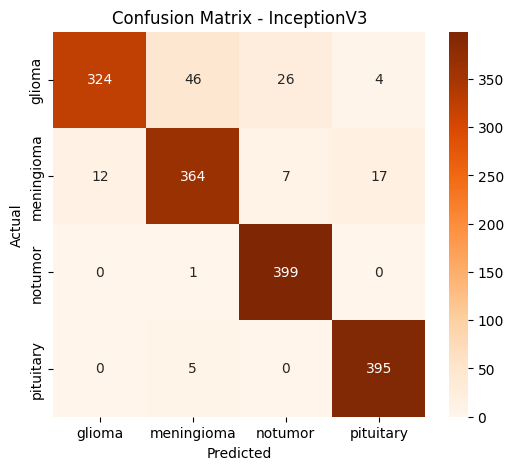

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_inc, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - InceptionV3")
plt.show()

In [ ]:
print("========== FULL MODEL COMPARISON ==========")
print(f"ResNet50  (frozen baseline)              : 84.69%")
print(f"ResNet50  (fine-tuned)                   : {test_acc*100:.2f}%")
print(f"DenseNet121 v1 (30 layers, lr=1e-5)      : {test_acc_d*100:.2f}%")
print(f"DenseNet121 v2 (60 layers, lr=3e-5)      : {test_acc_d2*100:.2f}%")
print(f"Custom CNN v1  (from scratch)            : 78.37%")
print(f"Custom CNN v2  (larger filters, lr=1e-4) : {test_acc_cnn2*100:.2f}%")
print(f"InceptionV3    (50 layers, lr=1e-5)      : {test_acc_inc*100:.2f}%")

========== FULL MODEL COMPARISON ==========
ResNet50  (frozen baseline)              : 84.69%


NameError: name 'test_acc' is not defined

In [ ]:
##8. InceptionV3 second run - 70 layers unfrozen

In [ ]:

base_inception = tf.keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)
base_inception.trainable = True
for layer in base_inception.layers[:-70]:
    layer.trainable = False

inputs = layers.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = inception_preprocess(x)
x = base_inception(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

inception_model_v2 = models.Model(inputs, outputs)

inception_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),  # was 1e-5
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
inception_model_v2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,810,980 (83.20 MB)

 Trainable params: 12,008,324 (45.81 MB)

 Non-trainable params: 9,802,656 (37.39 MB)

In [ ]:
callbacks_inception = [
    tf.keras.callbacks.ModelCheckpoint(
        "inceptionv3_v2_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

history_inception_v2 = inception_model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_inception
)

Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 46s 213ms/step - accuracy: 0.7471 - loss: 0.6788 - val_accuracy: 0.8560 - val_loss: 0.4174 - learning_rate: 2.0000e-05
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 30s 198ms/step - accuracy: 0.8960 - loss: 0.3033 - val_accuracy: 0.8988 - val_loss: 0.2578 - learning_rate: 2.0000e-05
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 29s 193ms/step - accuracy: 0.9212 - loss: 0.2144 - val_accuracy: 0.9262 - val_loss: 0.1929 - learning_rate: 2.0000e-05
Epoch 4/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 29s 194ms/step - accuracy: 0.9532 - loss: 0.1439 - val_accuracy: 0.9333 - val_loss: 0.1701 - learning_rate: 2.0000e-05
Epoch 5/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 30s 198ms/step - accuracy: 0.9655 - loss: 0.1067 - val_accuracy: 0.9512 - val_loss: 0.1398 - learning_rate: 2.0000e-05
Epoch 6/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 29s 196ms/step - accuracy: 0.9746 - loss: 0.0842 - val_accuracy: 0.9524 - val_loss: 0.1302 - learning_rate: 2.0000e-05
Epoch 7/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 29s 19

In [ ]:
test_loss_inc_v2, test_acc_inc_v2 = inception_model_v2.evaluate(test_ds)
print("InceptionV3 v2 Test acc:", test_acc_inc_v2)

y_pred_probs_inc_v2 = inception_model_v2.predict(test_ds)
y_pred_inc_v2 = np.argmax(y_pred_probs_inc_v2, axis=1)

cm_inc_v2 = confusion_matrix(y_true, y_pred_inc_v2)
print("Confusion Matrix:\n", cm_inc_v2)
print("\nClassification Report:")
print(classification_report(y_true, y_pred_inc_v2, target_names=class_names, digits=4))

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.9394 - loss: 0.2323
InceptionV3 v2 Test acc: 0.9393749833106995
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step
Confusion Matrix:
 [[325  44  29   2]
 [  3 384   4   9]
 [  0   1 399   0]
 [  0   5   0 395]]

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9909    0.8125    0.8929       400
  meningioma     0.8848    0.9600    0.9209       400
     notumor     0.9236    0.9975    0.9591       400
   pituitary     0.9729    0.9875    0.9801       400

    accuracy                         0.9394      1600
   macro avg     0.9430    0.9394    0.9383      1600
weighted avg     0.9430    0.9394    0.9383      1600



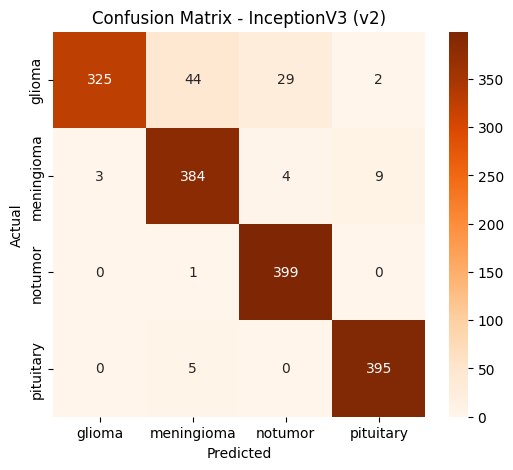

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_inc_v2, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - InceptionV3 (v2)")
plt.show()